# Multiwell mPCN P vs rho sweep

Run mPCN across P in [10, 20, 30, 40] and rho in [0.1, 0.9] (step 0.1), with 10k iterations each, and compare against MESS uniform and MESS euclid-squared.

## Notebook summary (auto)
- Defines a 2D multiwell forward map and Gaussian likelihood.
- Generates synthetic observations from a prior sample with additive noise.
- Configures mPCN/pCN sweeps over $\rho$ and $P$, plus diagnostics and caching.
- Runs chains, saves compressed samples/metrics, and reloads if present.
- Produces diagnostics/plots: proposal ellipses, traceplots, histograms, ESS/MSJD curves, rejection rates, and edge-$\rho$ zooms.
- Exports figures to reports/multiwell and tables for ESS/MSJD.

In [6]:
# import os
import sys
from pathlib import Path
import time
import json

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'pyproject.toml').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_path = repo_root / 'src'
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.algorithms.mpcn import mpcn_step, mpcn_chain
from multiproposal.algorithms.pcn import pcn_chain
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size
from multiproposal.problems.toy_custom_likelihood import ToyCustomLikelihood2D
from multiproposal.utils.run_paths import build_run_dirs, format_float_tag
from reports.figure_style import apply_pub_style

In [7]:
def f_16polynomic_wells(x):
    x1, x2 = x
    comp1 = (x1 ** 2 - 1) * (x1 ** 2 - 4)
    comp2 = (x2 ** 2 - 1) * (x2 ** 2 - 4)
    return np.array([comp1, comp2])


def log_likelihood_16polynomic(x, y_obs, sigma=0.3):
    r = f_16polynomic_wells(x) - y_obs
    return -0.5 * np.dot(r, r) / (sigma ** 2)

## Posterior formulation (16-polynomic wells)

Let $x = (x_1, x_2)^T \in \mathbb{R}^2$. The forward map defined in the code is

$$
f(x) = \begin{bmatrix}
(x_1^2 - 1)(x_1^2 - 4) \\
(x_2^2 - 1)(x_2^2 - 4)
\end{bmatrix}.
$$

The data are generated as

$$
x_{\text{true}} \sim \mathcal{N}(\mu, C), \quad y_{\text{obs}} = f(x_{\text{true}}) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_2),
$$

with $\mu = (0,0)^T$, $C = \text{prior\_std}^2 I_2$ and $\text{prior\_std}=1$ (so $C=I_2$), and $\sigma = \text{sigma\_noise}=1.0$ in this notebook.

The Gaussian likelihood implied by `log_likelihood_16polynomic` is

$$
p(y_{\text{obs}}\mid x) = (2\pi\sigma^2)^{-1}
\exp\left(-\frac{1}{2\sigma^2}\left\|f(x)-y_{\text{obs}}\right\|^2\right).
$$

The prior density is

$$
p(x) = (2\pi)^{-1} |C|^{-1/2}
\exp\left(-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu)\right).
$$

Therefore the posterior is

$$
p(x\mid y_{\text{obs}}) \propto
\exp\left(-\frac{1}{2\sigma^2}\left\|f(x)-y_{\text{obs}}\right\|^2
-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu)\right).
$$

Equivalently, the log-posterior (up to an additive constant) is

$$
\log p(x\mid y_{\text{obs}}) =
-\frac{1}{2\sigma^2}\left\|f(x)-y_{\text{obs}}\right\|^2
-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu) + \text{const}.
$$

In [8]:
# Match the data-generation pattern from the toy notebook
sigma_noise = 1.0
prior_std = 1.0
prior_cov = prior_std ** 2 * np.array([[1.0, 0.0], [0.0, 1.0]])
prior_mean = np.zeros(2)

data_seed = 202
rng = np.random.default_rng(data_seed)
prior_sample = rng.multivariate_normal(prior_mean, prior_cov)
theta_true = f_16polynomic_wells(prior_sample)
y_obs = theta_true + rng.normal(0.0, sigma_noise, size=theta_true.shape)

def log_likelihood(x):
    return log_likelihood_16polynomic(x, y_obs, sigma=sigma_noise)

problem = ToyCustomLikelihood2D(
    log_likelihood_fn=log_likelihood,
    prior_mean=prior_mean,
    prior_cov=prior_cov,
)

data_config = {
    'sigma_noise': sigma_noise,
    'prior_std': prior_std,
    'prior_cov': prior_cov.tolist(),
    'prior_mean': prior_mean.tolist(),
    'data_seed': data_seed,
}

print('y_obs:', y_obs)
print('True x:', prior_sample)
print('Log-posterior at prior mean:', problem.log_posterior(prior_mean))

y_obs: [-2.72358526  1.22300603]
True x: [ 1.81172035 -0.72905356]
Log-posterior at prior mean: -26.459147097660278


In [10]:
# Sweep configuration
n_iters = 50000
P_list = [10, 20, 30, 40]
# P_list = [10]
M_list = P_list
rho_list = [round(val, 2) for val in np.arange(0, 1.01, 0.05)]
burn_in = 5000
max_lag = 1500
plot_iter = 0
n_diag_samples = 100
seed_base = 202

algo_config = {
    'n_iters': n_iters,
    'burn_in': burn_in,
    'max_lag': max_lag,
    'n_diag_samples': n_diag_samples,
}
sweep_config = {
    'P_list': P_list,
    'M_list': M_list,
    'rho_list': rho_list,
    'seed_base': seed_base,
}
sigma_tag = format_float_tag(sigma_noise, precision=2)
prior_tag = format_float_tag(prior_std, precision=2)
tag_parts = [
    'sweep',
    'P_rho',
    f"iters{n_iters}",
    f"seed{seed_base}",
    f"sigma{sigma_tag}",
    f"prior{prior_tag}",
 ]
estimations_dir, reports_dir, run_name, run_config = build_run_dirs(
    repo_root,
    dataset='multiwell',
    algorithm='mpcn',
    data_config=data_config,
    algorithm_config=algo_config,
    algorithm_dir='',
    sweep_config=sweep_config,
    tag_parts=tag_parts,
 )

rng_init = np.random.default_rng(seed_base)
x0 = problem.sample_prior(rng_init)

print('P_list:', P_list)
print('M_list:', M_list)
print('rho_list:', rho_list)
print('n_iters:', n_iters)
print('burn_in:', burn_in)
print('max_lag:', max_lag)
print('n_diag_samples:', n_diag_samples)
print('Run directory:', estimations_dir)

P_list: [10, 20, 30, 40]
M_list: [10, 20, 30, 40]
rho_list: [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65), np.float64(0.7), np.float64(0.75), np.float64(0.8), np.float64(0.85), np.float64(0.9), np.float64(0.95), np.float64(1.0)]
n_iters: 50000
burn_in: 5000
max_lag: 1500
n_diag_samples: 100
Run directory: /home/senng/multiproposal-internal/estimations/multiwell/multiwell_mpcn_sweep_P_rho_iters50000_seed202_sigma1p00_prior1p00_h8b95b451c01f


In [11]:
def compute_msjd_per_param(chain):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    jumps = np.diff(chain, axis=0)
    msjd = np.mean(jumps * jumps, axis=0)
    return msjd


def compute_ess_per_param(chain, max_lag):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    variances = np.var(chain, axis=0)
    if np.all(variances == 0):
        return np.zeros(chain.shape[1])
    ess_vals = estimate_effective_sample_size(chain, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    ess_vals[variances == 0] = 0.0
    return ess_vals


def summarize_chain_metrics(chain, runtime_sec, burn_in, max_lag):
    post = chain[burn_in:]
    ess_vals = compute_ess_per_param(post, max_lag=max_lag)
    msjd_vals = compute_msjd_per_param(post)
    ess_mean = float(np.nanmean(ess_vals)) if ess_vals.size else 0.0
    msjd_mean = float(np.nanmean(msjd_vals)) if msjd_vals.size else 0.0
    runtime_min = runtime_sec / 60.0
    ess_per_min = ess_mean / runtime_min if runtime_min > 0 else np.nan
    return {
        'runtime_sec': runtime_sec,
        'runtime_min': runtime_min,
        'ess_mean': ess_mean,
        'msjd_mean': msjd_mean,
        'ess_per_min': ess_per_min,
        'ess_per_param': ess_vals.tolist(),
        'msjd_per_param': msjd_vals.tolist(),
    }


def rho_to_tag(rho):
    return format_float_tag(rho, precision=5)


def chain_cache_paths(method, rho, seed_base, P=None):
    rho_tag = rho_to_tag(rho)
    if P is None:
        stem = f"{method}_rho{rho_tag}_seed{seed_base}"
    else:
        stem = f"{method}_P{P}_rho{rho_tag}_seed{seed_base}"
    samples_path = estimations_dir / f"{stem}.npz"
    metrics_path = estimations_dir / f"{stem}_metrics.json"
    return samples_path, metrics_path


def mess_cache_paths(method, P, seed_base):
    stem = f"{method}_M{P}_seed{seed_base}"
    samples_path = estimations_dir / f"{stem}.npz"
    metrics_path = estimations_dir / f"{stem}_metrics.json"
    return samples_path, metrics_path


def save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec):
    payload = dict(metrics)
    payload['accept_rate'] = None if accept_rate is None else float(accept_rate)
    payload['runtime_sec'] = float(runtime_sec)
    with open(metrics_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)


def load_metrics_json(metrics_path):
    if not metrics_path.exists():
        return None
    with open(metrics_path, 'r', encoding='utf-8') as handle:
        return json.load(handle)


def save_chain_bundle(samples_path, metrics_path, chain, accept_rate, runtime_sec, metrics):
    accept_val = np.nan if accept_rate is None else float(accept_rate)
    np.savez_compressed(
        samples_path,
        chain=chain,
        accept_rate=accept_val,
        runtime_sec=float(runtime_sec),
    )
    save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)


def load_chain_bundle(samples_path, metrics_path):
    if not samples_path.exists():
        return None
    data = np.load(samples_path, allow_pickle=False)
    chain = data['chain']
    accept_rate = float(data['accept_rate']) if 'accept_rate' in data else np.nan
    if np.isnan(accept_rate):
        accept_rate = None
    runtime_sec = float(data['runtime_sec']) if 'runtime_sec' in data else 0.0
    metrics = load_metrics_json(metrics_path)
    return chain, accept_rate, runtime_sec, metrics


def mpcn_diag_path(P, rho, seed_base):
    rho_tag = rho_to_tag(rho)
    return estimations_dir / f"mpcn_P{P}_rho{rho_tag}_seed{seed_base}_diag.npz"


def save_mpcn_diagnostics(diag_path, snapshot, mean_dist_samples, mean_sq_dist_samples):
    if snapshot is None and (mean_dist_samples is None or len(mean_dist_samples) == 0):
        return
    np.savez_compressed(
        diag_path,
        snapshot=np.array(snapshot, dtype=object),
        mean_dist_samples=np.asarray(mean_dist_samples, dtype=float),
        mean_sq_dist_samples=np.asarray(mean_sq_dist_samples, dtype=float),
    )


def load_mpcn_diagnostics(diag_path):
    if not diag_path.exists():
        return None, np.asarray([], dtype=float), np.asarray([], dtype=float)
    data = np.load(diag_path, allow_pickle=True)
    snapshot = None
    if 'snapshot' in data:
        try:
            snapshot = data['snapshot'].item()
        except ValueError:
            snapshot = None
    mean_dist_samples = data['mean_dist_samples'] if 'mean_dist_samples' in data else np.asarray([], dtype=float)
    mean_sq_dist_samples = data['mean_sq_dist_samples'] if 'mean_sq_dist_samples' in data else np.asarray([], dtype=float)
    return snapshot, mean_dist_samples, mean_sq_dist_samples


def run_mpcn_chain(problem, x0, n_iters, rho, n_props, seed, diag_indices=None):
    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()
    return_diag = diag_indices is not None
    if return_diag:
        chain, accepted_index, diagnostics = mpcn_chain(
            x0,
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=n_props,
            return_indices=True,
            return_diagnostics=True,
            diag_indices=diag_indices,
        )
    else:
        chain, accepted_index = mpcn_chain(
            x0,
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=n_props,
            return_indices=True,
        )
        diagnostics = None
    runtime_sec = time.perf_counter() - t0
    accept_rate = float(np.mean(accepted_index != 0))
    return chain, runtime_sec, accept_rate, diagnostics


def run_mess_chain(problem, x0, n_iters, M, seed, use_lp=False, distance_metric='angular', lam=0.0):
    rng = np.random.default_rng(seed)
    chain = np.zeros((n_iters + 1, problem.dim), dtype=float)
    chain[0] = x0
    x = x0.copy()
    t0 = time.perf_counter()
    for t in range(n_iters):
        x, _, _ = mess_step(
            x,
            problem,
            rng,
            M=M,
            use_lp=use_lp,
            distance_metric=distance_metric,
            lam=lam,
        )
        chain[t + 1] = x
    runtime_sec = time.perf_counter() - t0
    return chain, runtime_sec

In [12]:
# Precompute likelihood grid for plotting
grid_min = -4.0
grid_max = 4.0
grid = np.linspace(grid_min, grid_max, 300)
X1, X2 = np.meshgrid(grid, grid)
log_like = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x_grid = np.array([X1[i, j], X2[i, j]])
        log_like[i, j] = log_likelihood_16polynomic(x_grid, y_obs, sigma=sigma_noise)
log_like -= log_like.max()
like_density = np.exp(log_like)

theta = np.linspace(0.0, 2.0 * np.pi, 800)
levels_fill = 50
levels_line = 14

In [13]:
# Run sweep
results = {'mpcn': {}, 'pcn': {}, 'mess_uniform': {}, 'mess_euclid_sq': {}}
run_pcn = True
run_mess = False

if run_pcn:
    for rho in rho_list:
        samples_path, metrics_path = chain_cache_paths('pcn', rho=rho, seed_base=seed_base)
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is not None:
            chain, accept_rate, runtime_sec, metrics = loaded
            if metrics is None or 'ess_per_param' not in metrics:
                metrics = summarize_chain_metrics(
                    chain, runtime_sec, burn_in=burn_in, max_lag=max_lag
                )
                save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)
            results['pcn'][rho] = {
                'chain': chain,
                'runtime_sec': runtime_sec,
                'accept_rate': accept_rate,
                'metrics': metrics,
            }
            accept_display = np.nan if accept_rate is None else accept_rate
            print(
                f'pCN loaded: rho={rho:.3f}, accept={accept_display:.3f}, runtime={runtime_sec:.2f}s'
            )
            continue
        seed = seed_base + int(round(rho * 100))
        rng = np.random.default_rng(seed)
        t0 = time.perf_counter()
        chain, accept_rate = pcn_chain(
            x0, problem, rng, n_iters, rho=rho, return_acceptance=True
        )
        runtime_sec = time.perf_counter() - t0
        metrics = summarize_chain_metrics(chain, runtime_sec, burn_in=burn_in, max_lag=max_lag)
        save_chain_bundle(samples_path, metrics_path, chain, accept_rate, runtime_sec, metrics)
        results['pcn'][rho] = {
            'chain': chain,
            'runtime_sec': runtime_sec,
            'accept_rate': accept_rate,
            'metrics': metrics,
        }
        print(f'pCN done: rho={rho:.3f}, accept={accept_rate:.3f}, runtime={runtime_sec:.2f}s')
else:
    print('pCN disabled (run_pcn=False).')

for P in P_list:
    results['mpcn'][P] = {}
    for rho in rho_list:
        samples_path, metrics_path = chain_cache_paths('mpcn', rho=rho, seed_base=seed_base, P=P)
        diag_path = mpcn_diag_path(P, rho, seed_base)
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is not None:
            chain, accept_rate, runtime_sec, metrics = loaded
            if metrics is None or 'ess_per_param' not in metrics:
                metrics = summarize_chain_metrics(
                    chain, runtime_sec, burn_in=burn_in, max_lag=max_lag
                )
                save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)
            snapshot, mean_dist_samples, mean_sq_dist_samples = load_mpcn_diagnostics(diag_path)
            results['mpcn'][P][rho] = {
                'chain': chain,
                'runtime_sec': runtime_sec,
                'accept_rate': accept_rate,
                'metrics': metrics,
                'snapshot': snapshot,
                'mean_dist_samples': np.asarray(mean_dist_samples, dtype=float),
                'mean_sq_dist_samples': np.asarray(mean_sq_dist_samples, dtype=float),
            }
            accept_display = np.nan if accept_rate is None else accept_rate
            print(
                f'mPCN loaded: P={P}, rho={rho:.3f}, accept={accept_display:.3f}, runtime={runtime_sec:.2f}s'
            )
            continue
        seed = seed_base + int(P * 1000 + round(rho * 100))

        rng_diag = np.random.default_rng(seed)
        diag_pool = np.arange(burn_in, n_iters)
        replace = n_diag_samples > diag_pool.size
        diag_indices = rng_diag.choice(diag_pool, size=n_diag_samples, replace=replace)

        chain, runtime_sec, accept_rate, diagnostics = run_mpcn_chain(
            problem, x0, n_iters, rho=rho, n_props=P, seed=seed, diag_indices=diag_indices
        )
        metrics = summarize_chain_metrics(chain, runtime_sec, burn_in=burn_in, max_lag=max_lag)

        mean_dist_samples = []
        mean_sq_dist_samples = []
        snapshot = None
        if diagnostics:
            for diag in diagnostics:
                x_diag = diag['x']
                log_l0 = problem.log_likelihood(x_diag)
                logy = log_l0  # focus on props with lik above current
                x_center = diag['x_center']
                nu_c = diag['nu_c']
                props = diag['props']
                candidates = diag['candidates']
                diff = props - x_center[None, :]
                mean_dist = float(np.mean(np.linalg.norm(diff, axis=1)))
                mean_sq_dist = float(np.mean(np.sum(diff * diff, axis=1)))
                mean_dist_samples.append(mean_dist)
                mean_sq_dist_samples.append(mean_sq_dist)
                if snapshot is None:
                    snapshot = {
                        'iter': int(diag['iter']),
                        'x': x_diag.copy(),
                        'x_center': x_center.copy(),
                        'nu_c': nu_c.copy(),
                        'props': props.copy(),
                        'candidates': candidates.copy(),
                        'logy': logy,
                        'accepted_idx': int(diag['accepted_idx']),
                        'mean_dist': mean_dist,
                        'mean_sq_dist': mean_sq_dist,
                    }

        save_chain_bundle(samples_path, metrics_path, chain, accept_rate, runtime_sec, metrics)
        save_mpcn_diagnostics(diag_path, snapshot, mean_dist_samples, mean_sq_dist_samples)

        results['mpcn'][P][rho] = {
            'chain': chain,
            'runtime_sec': runtime_sec,
            'accept_rate': accept_rate,
            'metrics': metrics,
            'snapshot': snapshot,
            'mean_dist_samples': np.asarray(mean_dist_samples, dtype=float),
            'mean_sq_dist_samples': np.asarray(mean_sq_dist_samples, dtype=float),
        }
        print(f'mPCN done: P={P}, rho={rho:.3f}, accept={accept_rate:.3f}, runtime={runtime_sec:.2f}s')

    if run_mess:
        seed_mess = seed_base + P
        samples_path, metrics_path = mess_cache_paths('mess_uniform', P=P, seed_base=seed_base)
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is not None:
            mess_chain, _, mess_runtime, mess_metrics = loaded
            if mess_metrics is None or 'ess_per_param' not in mess_metrics:
                mess_metrics = summarize_chain_metrics(
                    mess_chain, mess_runtime, burn_in=burn_in, max_lag=max_lag
                )
                save_metrics_json(metrics_path, mess_metrics, None, mess_runtime)
            results['mess_uniform'][P] = {
                'chain': mess_chain,
                'runtime_sec': mess_runtime,
                'metrics': mess_metrics,
            }
            print(f'MESS uniform loaded: M={P}, runtime={mess_runtime:.2f}s')
        else:
            mess_chain, mess_runtime = run_mess_chain(
                problem, x0, n_iters, M=P, seed=seed_mess, use_lp=False, distance_metric='angular', lam=0.0
            )
            mess_metrics = summarize_chain_metrics(
                mess_chain, mess_runtime, burn_in=burn_in, max_lag=max_lag
            )
            save_chain_bundle(samples_path, metrics_path, mess_chain, None, mess_runtime, mess_metrics)
            results['mess_uniform'][P] = {
                'chain': mess_chain,
                'runtime_sec': mess_runtime,
                'metrics': mess_metrics,
            }
            print(f'MESS uniform done: M={P}, runtime={mess_runtime:.2f}s')

        seed_mess_lp = seed_base + P
        samples_path, metrics_path = mess_cache_paths('mess_euclid_sq', P=P, seed_base=seed_base)
        loaded = load_chain_bundle(samples_path, metrics_path)
        if loaded is not None:
            mess_lp_chain, _, mess_lp_runtime, mess_lp_metrics = loaded
            if mess_lp_metrics is None or 'ess_per_param' not in mess_lp_metrics:
                mess_lp_metrics = summarize_chain_metrics(
                    mess_lp_chain, mess_lp_runtime, burn_in=burn_in, max_lag=max_lag
                )
                save_metrics_json(metrics_path, mess_lp_metrics, None, mess_lp_runtime)
            results['mess_euclid_sq'][P] = {
                'chain': mess_lp_chain,
                'runtime_sec': mess_lp_runtime,
                'metrics': mess_lp_metrics,
            }
            print(f'MESS euclid_sq loaded: M={P}, runtime={mess_lp_runtime:.2f}s')
        else:
            mess_lp_chain, mess_lp_runtime = run_mess_chain(
                problem, x0, n_iters, M=P, seed=seed_mess_lp, use_lp=True, distance_metric='euclidean_squared', lam=0.0
            )
            mess_lp_metrics = summarize_chain_metrics(
                mess_lp_chain, mess_lp_runtime, burn_in=burn_in, max_lag=max_lag
            )
            save_chain_bundle(samples_path, metrics_path, mess_lp_chain, None, mess_lp_runtime, mess_lp_metrics)
            results['mess_euclid_sq'][P] = {
                'chain': mess_lp_chain,
                'runtime_sec': mess_lp_runtime,
                'metrics': mess_lp_metrics,
            }
            print(f'MESS euclid_sq done: M={P}, runtime={mess_lp_runtime:.2f}s')
    else:
        results['mess_uniform'][P] = None
        results['mess_euclid_sq'][P] = None
        print(f'MESS disabled for M={P} (run_mess=False).')

Estimating ESS for each parameter.
pCN done: rho=0.000, accept=0.081, runtime=0.31s
Estimating ESS for each parameter.
pCN done: rho=0.050, accept=0.082, runtime=0.30s
Estimating ESS for each parameter.
pCN done: rho=0.100, accept=0.085, runtime=0.31s
Estimating ESS for each parameter.
pCN done: rho=0.150, accept=0.084, runtime=0.30s
Estimating ESS for each parameter.
pCN done: rho=0.200, accept=0.081, runtime=0.31s
Estimating ESS for each parameter.
pCN done: rho=0.250, accept=0.084, runtime=0.31s
Estimating ESS for each parameter.
pCN done: rho=0.300, accept=0.083, runtime=0.30s
Estimating ESS for each parameter.
pCN done: rho=0.350, accept=0.091, runtime=0.31s
Estimating ESS for each parameter.
pCN done: rho=0.400, accept=0.092, runtime=0.31s
Estimating ESS for each parameter.
pCN done: rho=0.450, accept=0.096, runtime=0.31s
Estimating ESS for each parameter.
pCN done: rho=0.500, accept=0.098, runtime=0.31s
Estimating ESS for each parameter.
pCN done: rho=0.550, accept=0.103, runtim

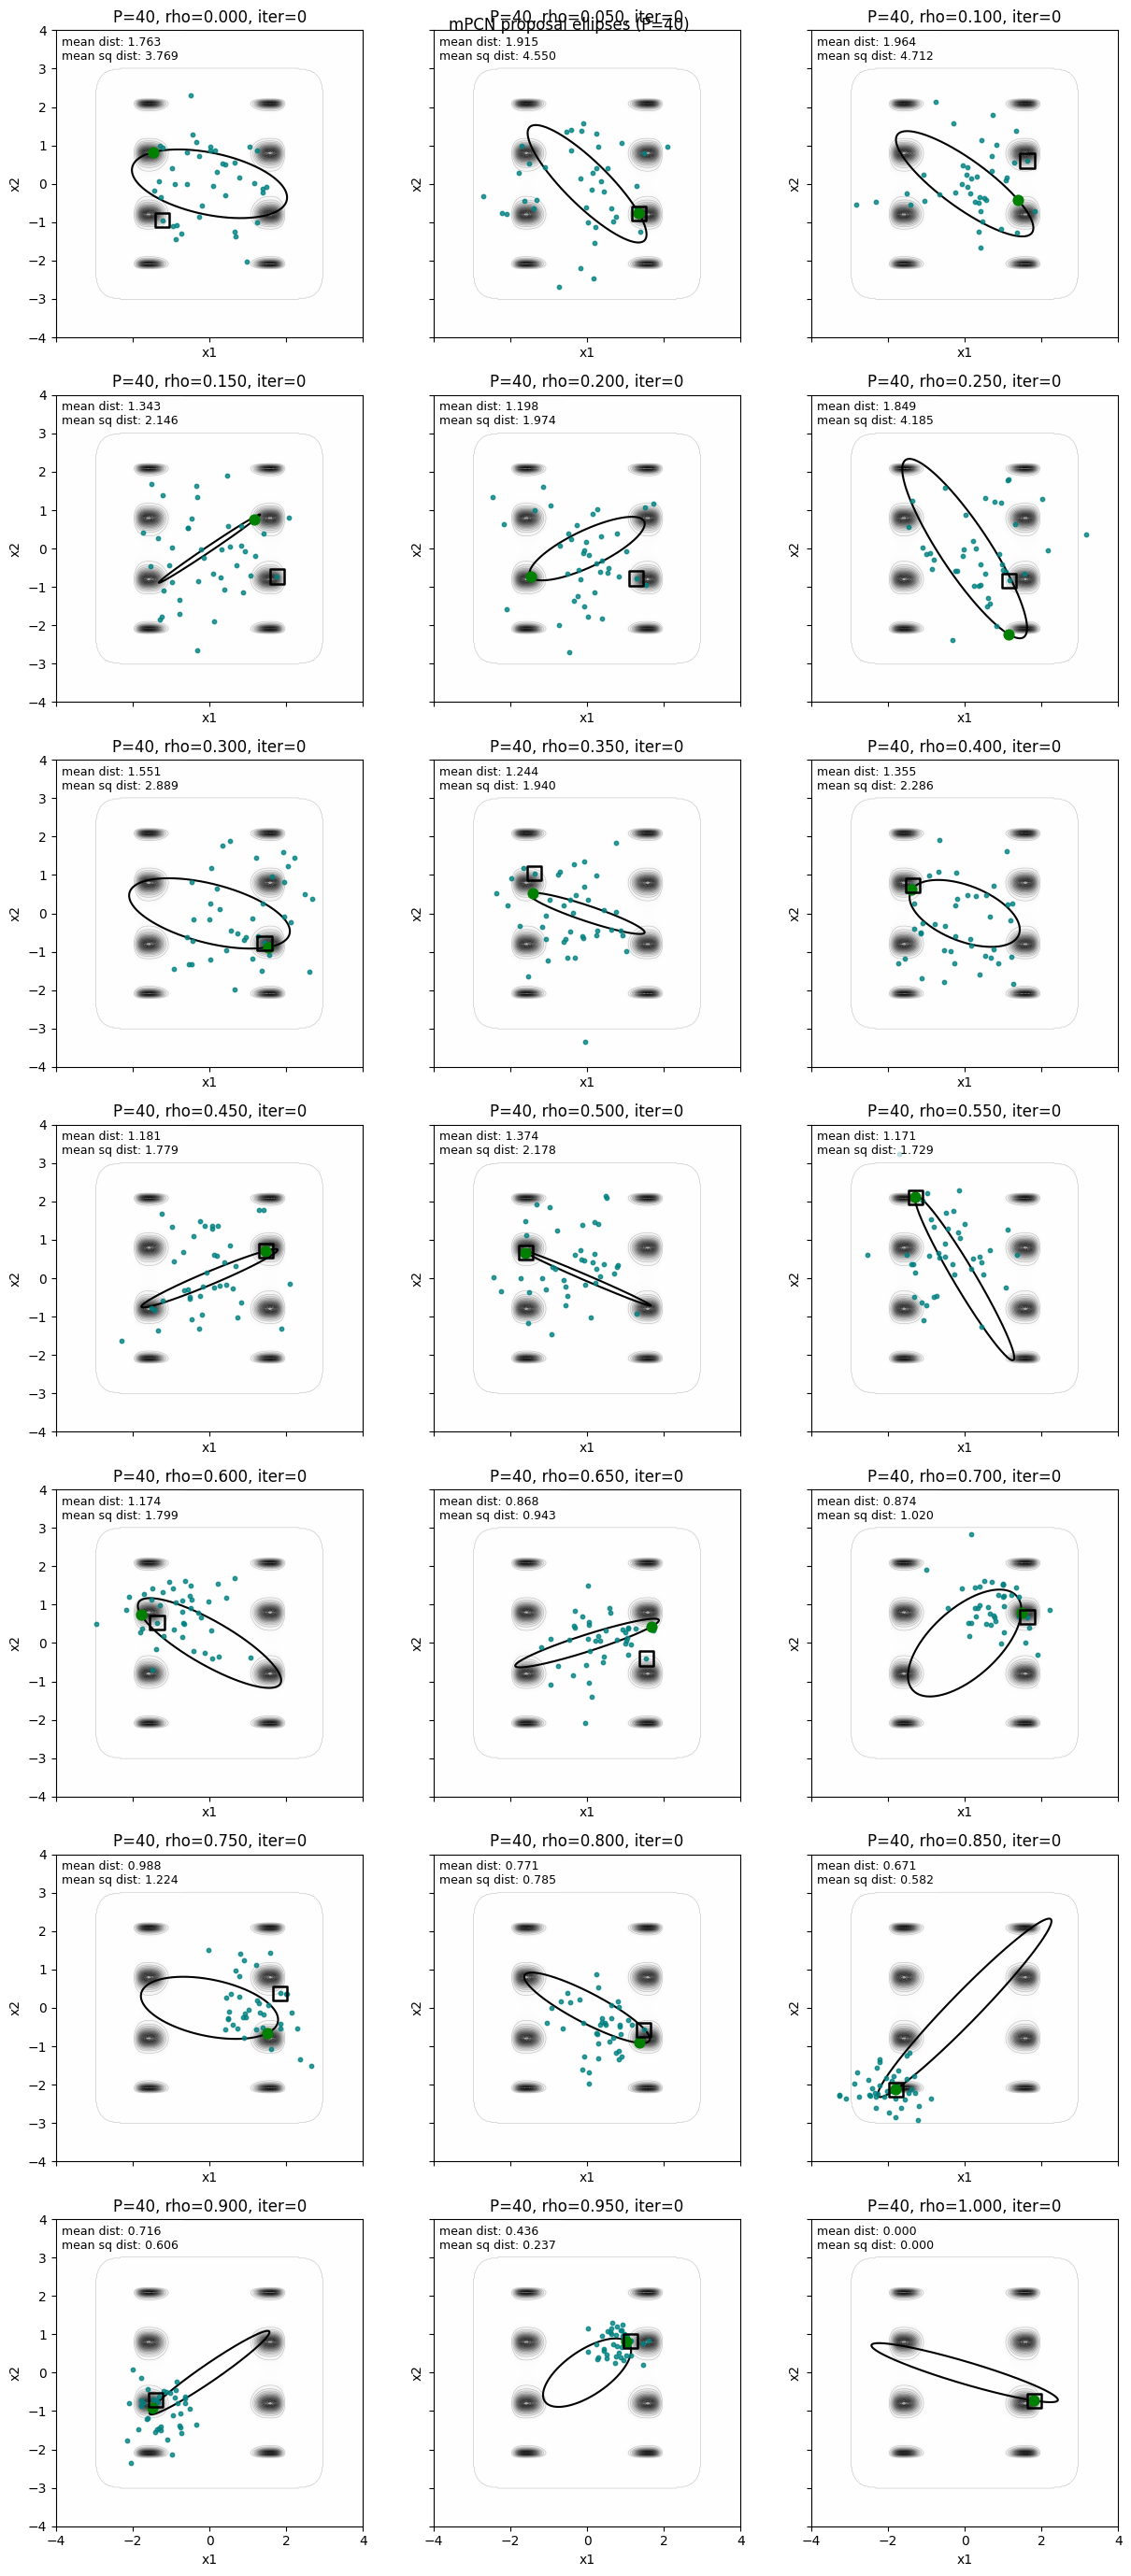

In [14]:
def plot_mpcn_snapshot(ax, snapshot, P, rho, iter_idx):
    mu = problem.prior_mean()
    x = snapshot['x']
    nu_c = snapshot['nu_c']
    props = snapshot['props']
    candidates = snapshot['candidates']
    logy = snapshot['logy']
    accepted_idx = snapshot['accepted_idx']
    mean_dist = snapshot['mean_dist']
    mean_sq_dist = snapshot['mean_sq_dist']
    ellipse = mu + np.cos(theta)[:, None] * (x - mu) + np.sin(theta)[:, None] * nu_c

    ax.contourf(X1, X2, like_density, levels=levels_fill, cmap='Greys', alpha=0.35)
    ax.contour(X1, X2, like_density, levels=levels_line, colors='black', linewidths=0.5, alpha=0.2)
    ax.plot(ellipse[:, 0], ellipse[:, 1], color='black', linewidth=1.5, zorder=2)

    prop_log_like = np.array([problem.log_likelihood(p) for p in props])
    above = prop_log_like >= logy
    ax.scatter(props[~above, 0], props[~above, 1], color='teal', s=10, alpha=0.8, label='props < logy', zorder=2)
    ax.scatter(props[above, 0], props[above, 1], color='teal', s=10, alpha=0.8, label='props >= logy', zorder=2)
    ax.scatter([x[0]], [x[1]], color='green', s=60, marker='o', label='current', zorder=3)
    accepted_point = candidates[accepted_idx]
    ax.scatter([accepted_point[0]], [accepted_point[1]], facecolors='none', edgecolors='black',
               s=120, marker='s', linewidths=1.8, label='accepted', zorder=4)
    ax.text(
        0.02,
        0.98,
        f'mean dist: {mean_dist:.3f}\nmean sq dist: {mean_sq_dist:.3f}',
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
    )
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.grid(False)
    ax.set_title(f'P={P}, rho={rho:.3f}, iter={iter_idx}')


reports_dir.mkdir(parents=True, exist_ok=True)

# Ellipse plots: one figure per P, subplots by rho
n_rho = len(rho_list)
ncols = 3
nrows = int(np.ceil(n_rho / ncols))

for P in P_list[-1:]:
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)
    for ax, rho in zip(axes, rho_list):
        snapshot = results['mpcn'][P][rho]['snapshot']
        if snapshot is None:
            ax.text(
                0.5,
                0.5,
                'No snapshot loaded',
                transform=ax.transAxes,
                ha='center',
                va='center',
                fontsize=10,
            )
            ax.set_aspect('equal', adjustable='box')
            ax.set_title(f'P={P}, rho={rho:.3f}, iter={plot_iter}')
            ax.axis('off')
            continue
        plot_mpcn_snapshot(ax, snapshot, P, rho, plot_iter)
    for ax in axes[len(rho_list):]:
        ax.axis('off')
    fig.suptitle(f'mPCN proposal ellipses (P={P})')
    fig.tight_layout()
    fig.savefig(
        reports_dir / f'02_multiwell_mpcn_ellipses_P{P}_seed{seed_base}.png',
        dpi=300,
        bbox_inches='tight',
    )
    plt.show()

In [ ]:
# # Distance summaries vs rho (one curve per P)
# P_sorted = sorted(P_list)
# colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
# color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}

# fig, ax = plt.subplots(figsize=(7, 4))
# for P in P_list:
#     dist_vals = [np.mean(results['mpcn'][P][rho]['mean_dist_samples']) for rho in rho_list]
#     ax.plot(rho_list, dist_vals, marker='o', color=color_by_P[P], label=f'P={P}')
# ax.set_xlabel('rho')
# ax.set_ylabel('Mean distance to center (avg over samples)')
# ax.set_title('Multiwell: mean distance vs rho (mPCN)')
# ax.grid(alpha=0.3)
# ax.legend(loc='best')
# plt.show()

# for P in P_list:
#     fig, ax = plt.subplots(figsize=(8, 4))
#     dist_samples = [results['mpcn'][P][rho]['mean_dist_samples'] for rho in rho_list]
#     ax.boxplot(dist_samples, widths=0.6, showfliers=False)
#     ax.set_xticks(np.arange(1, len(rho_list) + 1))
#     ax.set_xticklabels([f'{rho:.1f}' for rho in rho_list])
#     ax.set_xlabel('rho')
#     ax.set_ylabel('Mean distance to center (per step)')
#     ax.set_title(f'Multiwell: mean distance distribution (P={P})')
#     ax.grid(alpha=0.3, axis='y')
#     plt.show()

# fig, ax = plt.subplots(figsize=(7, 4))
# for P in P_list:
#     dist_vals = [np.mean(results['mpcn'][P][rho]['mean_sq_dist_samples']) for rho in rho_list]
#     ax.plot(rho_list, dist_vals, marker='o', color=color_by_P[P], label=f'P={P}')
# ax.set_xlabel('rho')
# ax.set_ylabel('Mean squared distance to center (avg over samples)')
# ax.set_title('Multiwell: mean squared distance vs rho (mPCN)')
# ax.grid(alpha=0.3)
# ax.legend(loc='best')
# plt.show()

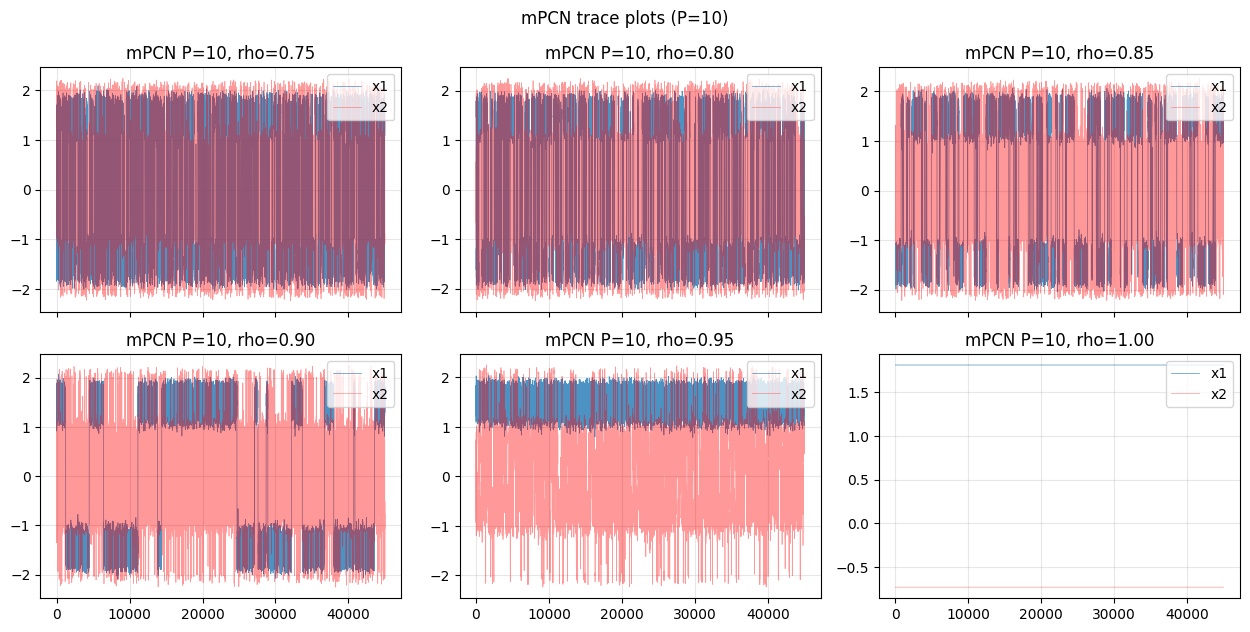

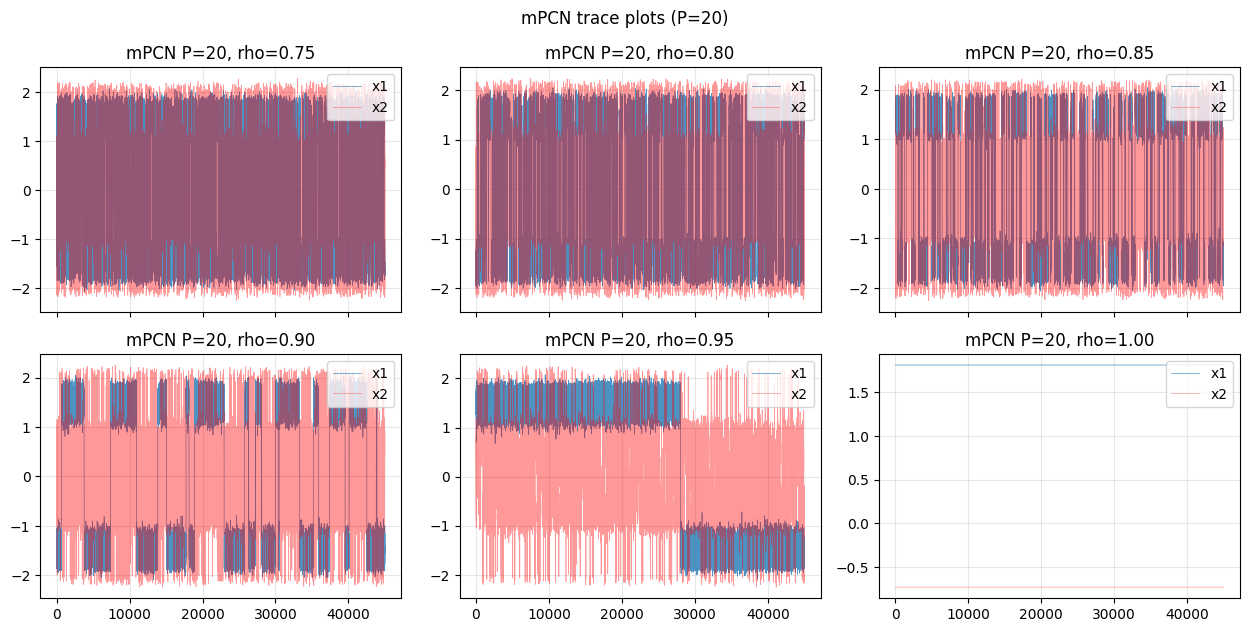

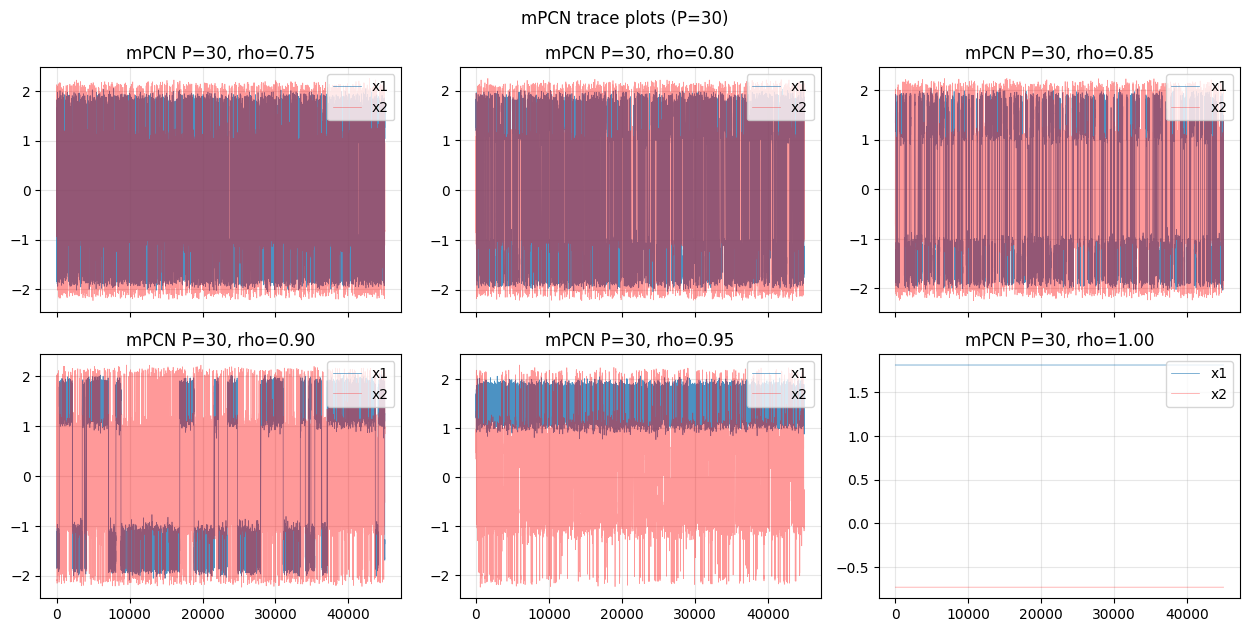

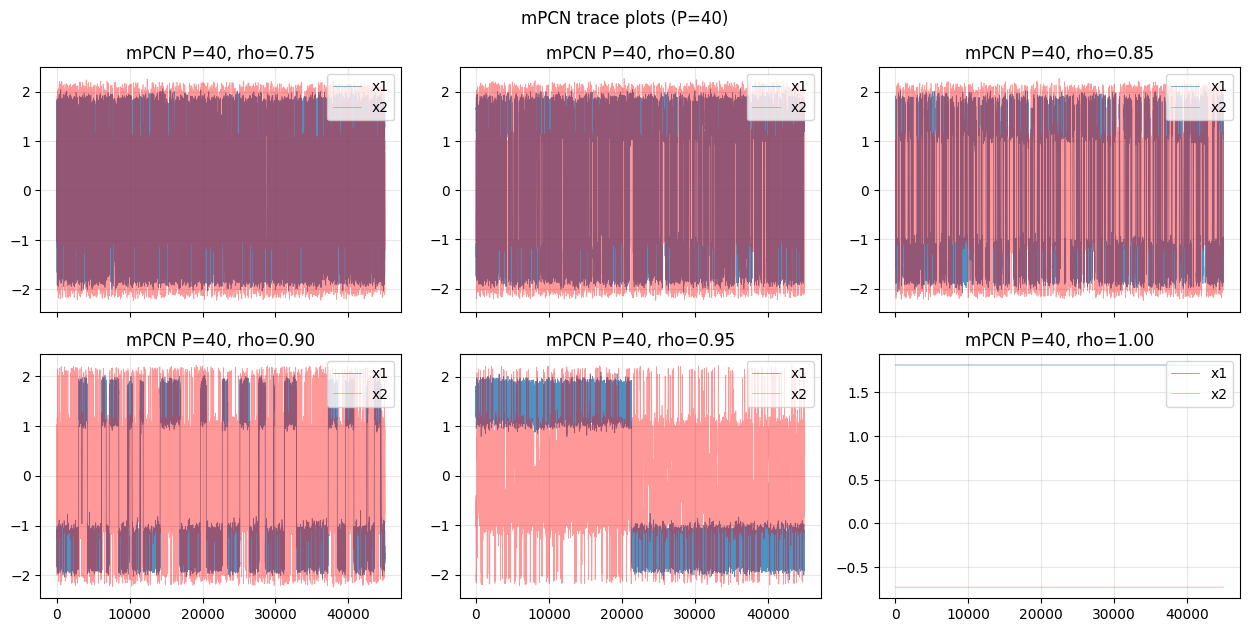

In [15]:
# Trace plots: one figure per P, subplots by rho
rho_list_plot = rho_list[-6:]  # plot only last 6 rhos to avoid overcrowding
n_rho = len(rho_list)
ncols = 3
nrows = int(np.ceil(len(rho_list_plot) / ncols))

for P in P_list:
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)
    for ax, rho in zip(axes, rho_list_plot):
        chain = results['mpcn'][P][rho]['chain'][burn_in:]
        ax.plot(chain[:, 0], color='#1f77b4', linewidth=0.5, label='x1', alpha=0.8)
        ax.plot(chain[:, 1], color='red', linewidth=0.5, label='x2', alpha=0.4)
        ax.set_title(f'mPCN P={P}, rho={rho:.2f}')
        ax.grid(alpha=0.3)
        ax.legend(loc='upper right')
    for ax in axes[len(rho_list):]:
        ax.axis('off')
    fig.suptitle(f'mPCN trace plots (P={P})')
    fig.tight_layout()
    plt.savefig(reports_dir / f'02_multiwell_mpcn_traces_P{P}_last6_seed{seed_base}.png', dpi=300)
    plt.show()

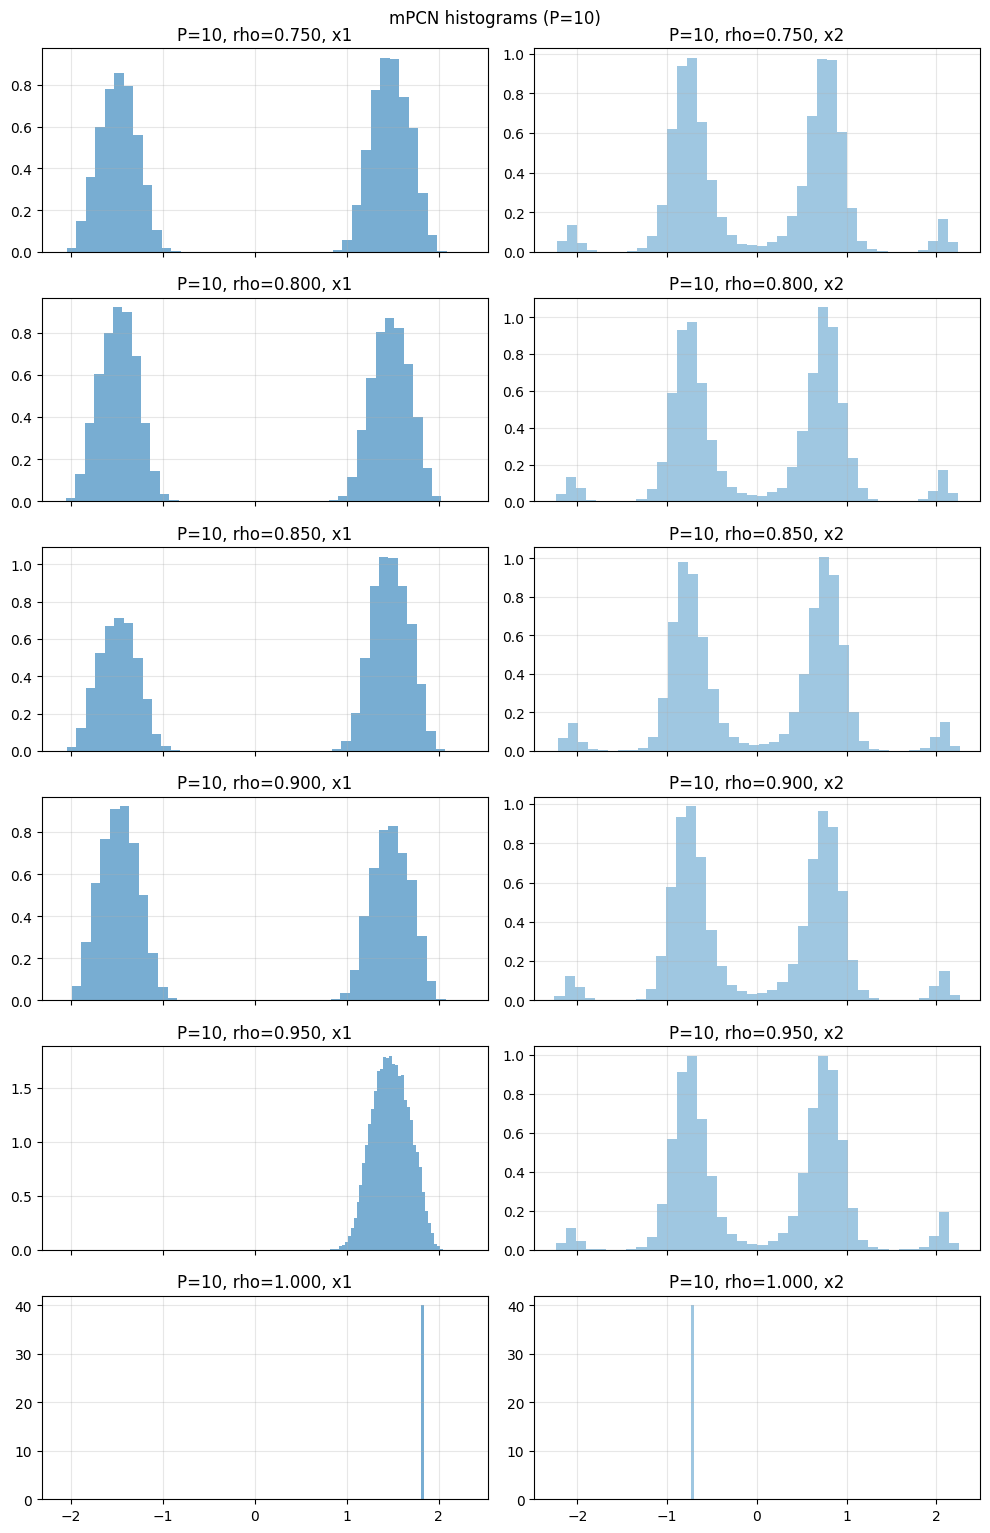

In [16]:
# Histograms: one figure per P, each rho has two subplots (x1, x2)
bins = 40
for P in P_list[:1]:
    fig, axes = plt.subplots(len(rho_list_plot), 2, figsize=(10, 2.6 * len(rho_list_plot)), sharex='col')
    for row_idx, rho in enumerate(rho_list_plot):
        chain = results['mpcn'][P][rho]['chain'][burn_in:]
        ax1 = axes[row_idx, 0]
        ax2 = axes[row_idx, 1]
        ax1.hist(chain[:, 0], bins=bins, density=True, color='#1f77b4', alpha=0.6)
        ax2.hist(chain[:, 1], bins=bins, density=True, color='#5fa2ce', alpha=0.6)
        ax1.set_title(f'P={P}, rho={rho:.3f}, x1')
        ax2.set_title(f'P={P}, rho={rho:.3f}, x2')
        ax1.grid(alpha=0.3)
        ax2.grid(alpha=0.3)
    fig.suptitle(f'mPCN histograms (P={P})')
    fig.tight_layout()
    plt.savefig(reports_dir / f'02_multiwell_mpcn_histograms_P{P}_last6_seed{seed_base}.png', dpi=300)
    plt.show()

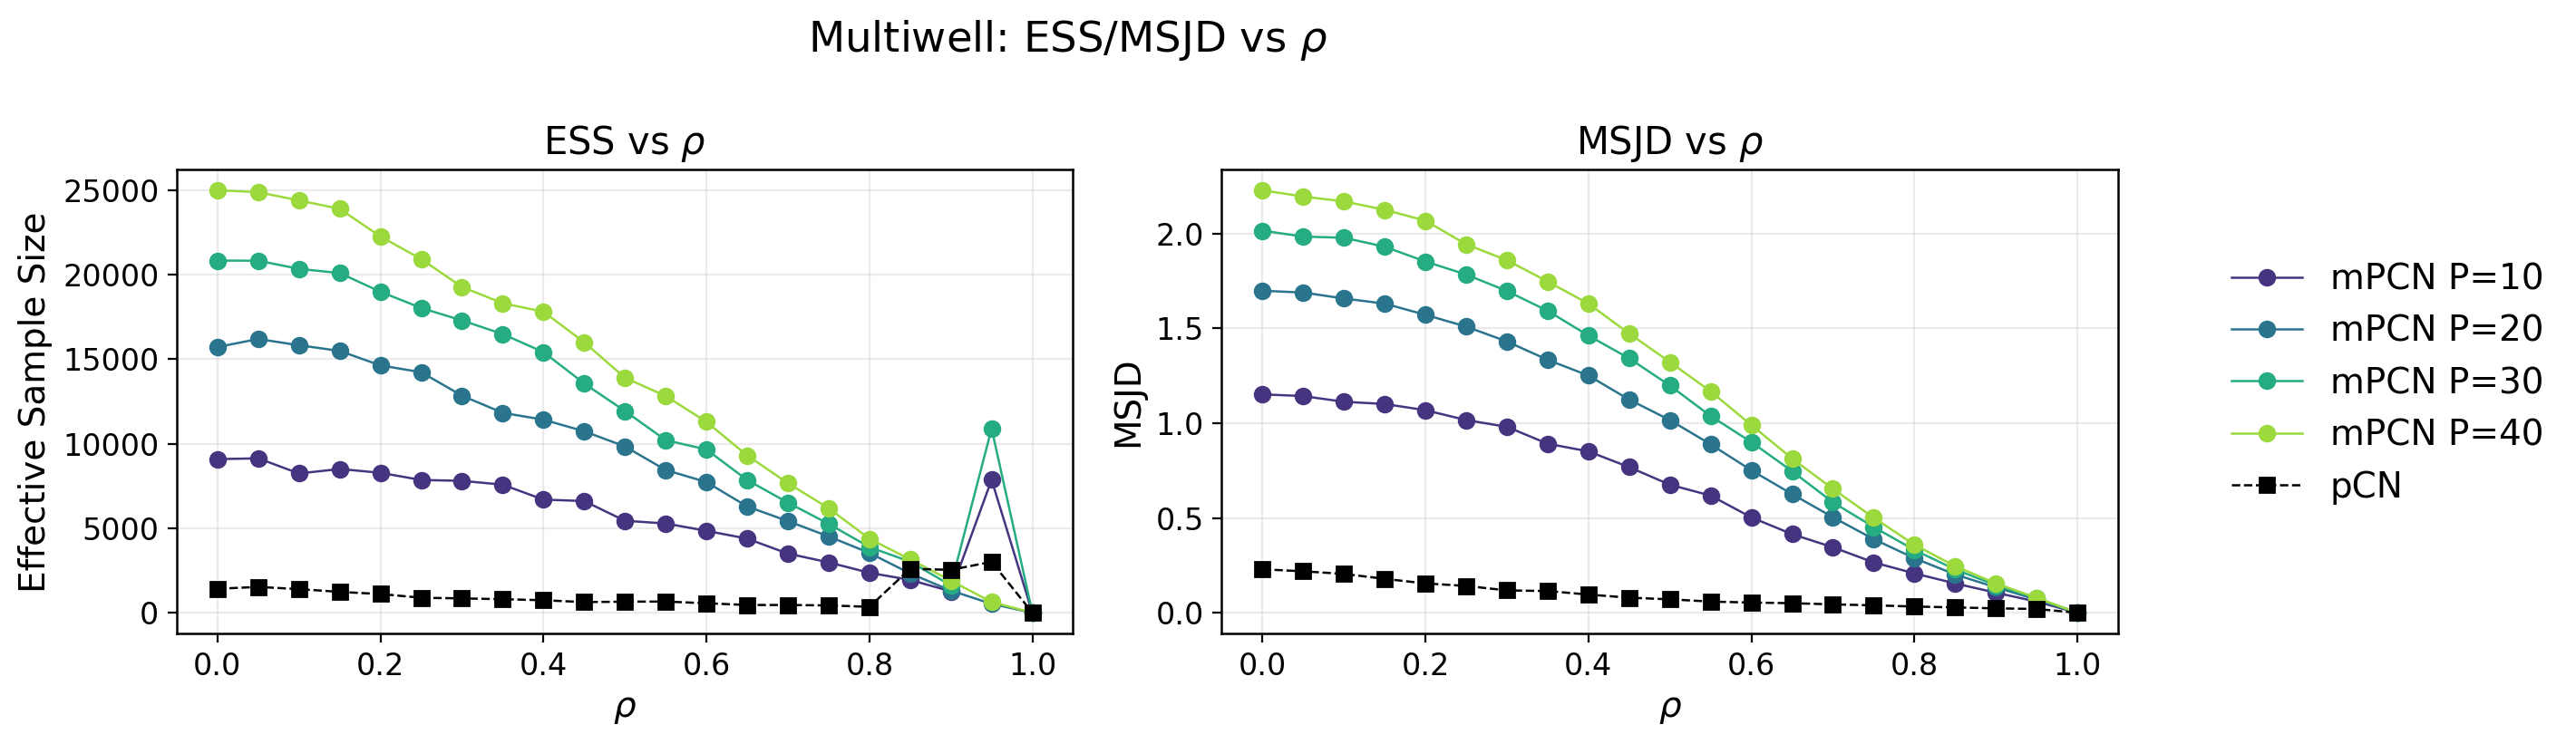

In [17]:
# ESS/MSJD vs rho curves (one line per P)
apply_pub_style()

P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}
show_mess = False
show_pcn = True

pcn_ess = None
pcn_msjd = None
if run_pcn and results['pcn']:
    pcn_ess = [results['pcn'][rho]['metrics']['ess_mean'] for rho in rho_list]
    pcn_msjd = [results['pcn'][rho]['metrics']['msjd_mean'] for rho in rho_list]

reports_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), sharex=True)
ax_ess, ax_msjd = axes

for P in P_sorted:
    ess_vals = [results['mpcn'][P][rho]['metrics']['ess_mean'] for rho in rho_list]
    ax_ess.plot(rho_list, ess_vals, marker='o', color=color_by_P[P], label=f'mPCN P={P}')
if show_pcn and pcn_ess is not None:
    ax_ess.plot(rho_list, pcn_ess, color='black', marker='s', linestyle='--', label='pCN')
if show_mess and run_mess:
    for P in P_sorted:
        mess_uniform = results['mess_uniform'][P]['metrics']['ess_mean']
        mess_euclid = results['mess_euclid_sq'][P]['metrics']['ess_mean']
        ax_ess.plot(rho_list, [mess_uniform] * len(rho_list), linestyle='--', color=color_by_P[P], alpha=0.6)
        ax_ess.plot(rho_list, [mess_euclid] * len(rho_list), linestyle=':', color=color_by_P[P], alpha=0.6)
ax_ess.set_xlabel(r'$\rho$')
ax_ess.set_ylabel('Effective Sample Size')
ax_ess.set_title(r'ESS vs $\rho$')
ax_ess.grid(alpha=0.25)

for P in P_sorted:
    msjd_vals = [results['mpcn'][P][rho]['metrics']['msjd_mean'] for rho in rho_list]
    ax_msjd.plot(rho_list, msjd_vals, marker='o', color=color_by_P[P], label=f'mPCN P={P}')
if show_pcn and pcn_msjd is not None:
    ax_msjd.plot(rho_list, pcn_msjd, color='black', marker='s', linestyle='--', label='pCN')
if show_mess and run_mess:
    for P in P_sorted:
        mess_uniform = results['mess_uniform'][P]['metrics']['msjd_mean']
        mess_euclid = results['mess_euclid_sq'][P]['metrics']['msjd_mean']
        ax_msjd.plot(rho_list, [mess_uniform] * len(rho_list), linestyle='--', color=color_by_P[P], alpha=0.6)
        ax_msjd.plot(rho_list, [mess_euclid] * len(rho_list), linestyle=':', color=color_by_P[P], alpha=0.6)
ax_msjd.set_xlabel(r'$\rho$')
ax_msjd.set_ylabel('MSJD')
ax_msjd.set_title(r'MSJD vs $\rho$')
ax_msjd.grid(alpha=0.25)

handles = []
labels = []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:
            labels.append(ll)
            handles.append(hh)
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(r'Multiwell: ESS/MSJD vs $\rho$')
fig.tight_layout()
fig.savefig(reports_dir / f'multiwell_ess_msjd_vs_rho_seed{seed_base}.png', bbox_inches='tight')
plt.show()

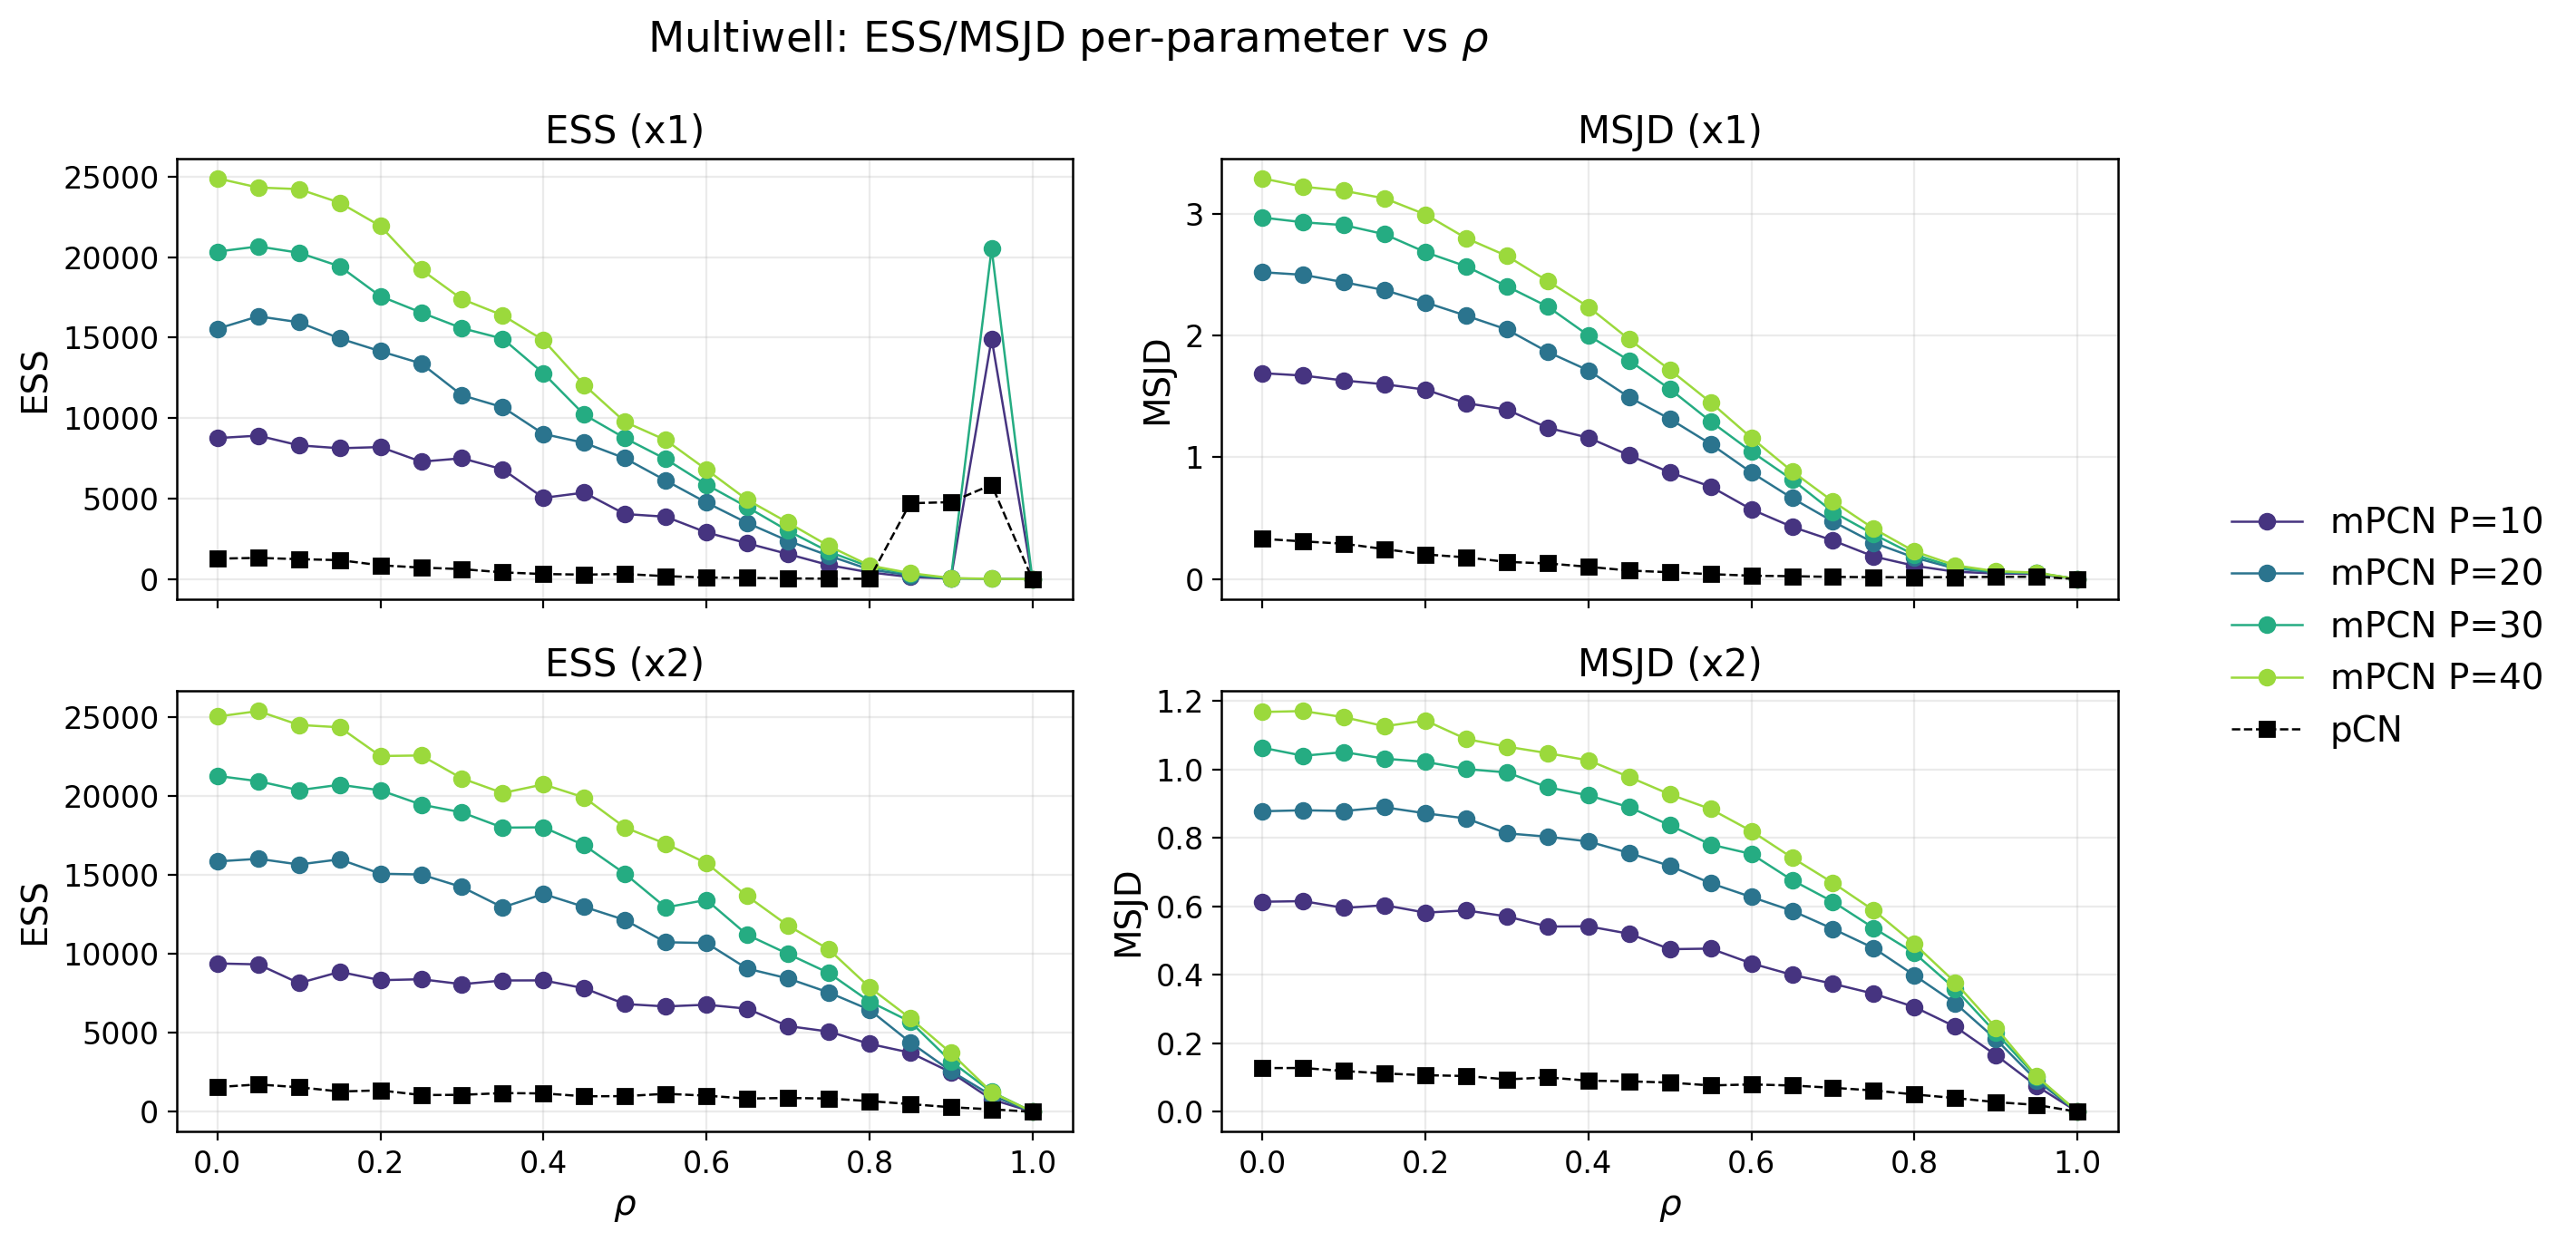

In [18]:
# ESS/MSJD per-parameter vs rho (full range + edges)
apply_pub_style()

P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}
show_pcn = True

def get_param_metric(results_dict, P, rho, metric_key, param_index):
    entry = results_dict.get(P, {}).get(float(rho))
    if entry is None:
        return np.nan
    values = entry['metrics'].get(metric_key)
    if values is None or len(values) <= param_index:
        return np.nan
    return values[param_index]

reports_dir.mkdir(parents=True, exist_ok=True)

# Full rho range
fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.0), sharex=True)
for P in P_sorted:
    ess_x1 = [get_param_metric(results['mpcn'], P, rho, 'ess_per_param', 0) for rho in rho_list]
    ess_x2 = [get_param_metric(results['mpcn'], P, rho, 'ess_per_param', 1) for rho in rho_list]
    msjd_x1 = [get_param_metric(results['mpcn'], P, rho, 'msjd_per_param', 0) for rho in rho_list]
    msjd_x2 = [get_param_metric(results['mpcn'], P, rho, 'msjd_per_param', 1) for rho in rho_list]
    axes[0, 0].plot(rho_list, ess_x1, marker='o', color=color_by_P[P], label=f'mPCN P={P}')
    axes[1, 0].plot(rho_list, ess_x2, marker='o', color=color_by_P[P])
    axes[0, 1].plot(rho_list, msjd_x1, marker='o', color=color_by_P[P])
    axes[1, 1].plot(rho_list, msjd_x2, marker='o', color=color_by_P[P])

if show_pcn and run_pcn and results['pcn']:
    pcn_ess_x1 = [results['pcn'][rho]['metrics']['ess_per_param'][0] for rho in rho_list]
    pcn_ess_x2 = [results['pcn'][rho]['metrics']['ess_per_param'][1] for rho in rho_list]
    pcn_msjd_x1 = [results['pcn'][rho]['metrics']['msjd_per_param'][0] for rho in rho_list]
    pcn_msjd_x2 = [results['pcn'][rho]['metrics']['msjd_per_param'][1] for rho in rho_list]
    axes[0, 0].plot(rho_list, pcn_ess_x1, color='black', marker='s', linestyle='--', label='pCN')
    axes[1, 0].plot(rho_list, pcn_ess_x2, color='black', marker='s', linestyle='--')
    axes[0, 1].plot(rho_list, pcn_msjd_x1, color='black', marker='s', linestyle='--')
    axes[1, 1].plot(rho_list, pcn_msjd_x2, color='black', marker='s', linestyle='--')

axes[0, 0].set_title('ESS (x1)')
axes[0, 1].set_title('MSJD (x1)')
axes[1, 0].set_title('ESS (x2)')
axes[1, 1].set_title('MSJD (x2)')
for ax in axes[1, :]:
    ax.set_xlabel(r'$\rho$')
axes[0, 0].set_ylabel('ESS')
axes[1, 0].set_ylabel('ESS')
axes[0, 1].set_ylabel('MSJD')
axes[1, 1].set_ylabel('MSJD')
for ax in axes.ravel():
    ax.grid(alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(r'Multiwell: ESS/MSJD per-parameter vs $\rho$')
fig.tight_layout()
fig.savefig(
    reports_dir / f'multiwell_ess_msjd_per_param_vs_rho_seed{seed_base}.png',
    bbox_inches='tight',
)
plt.show()


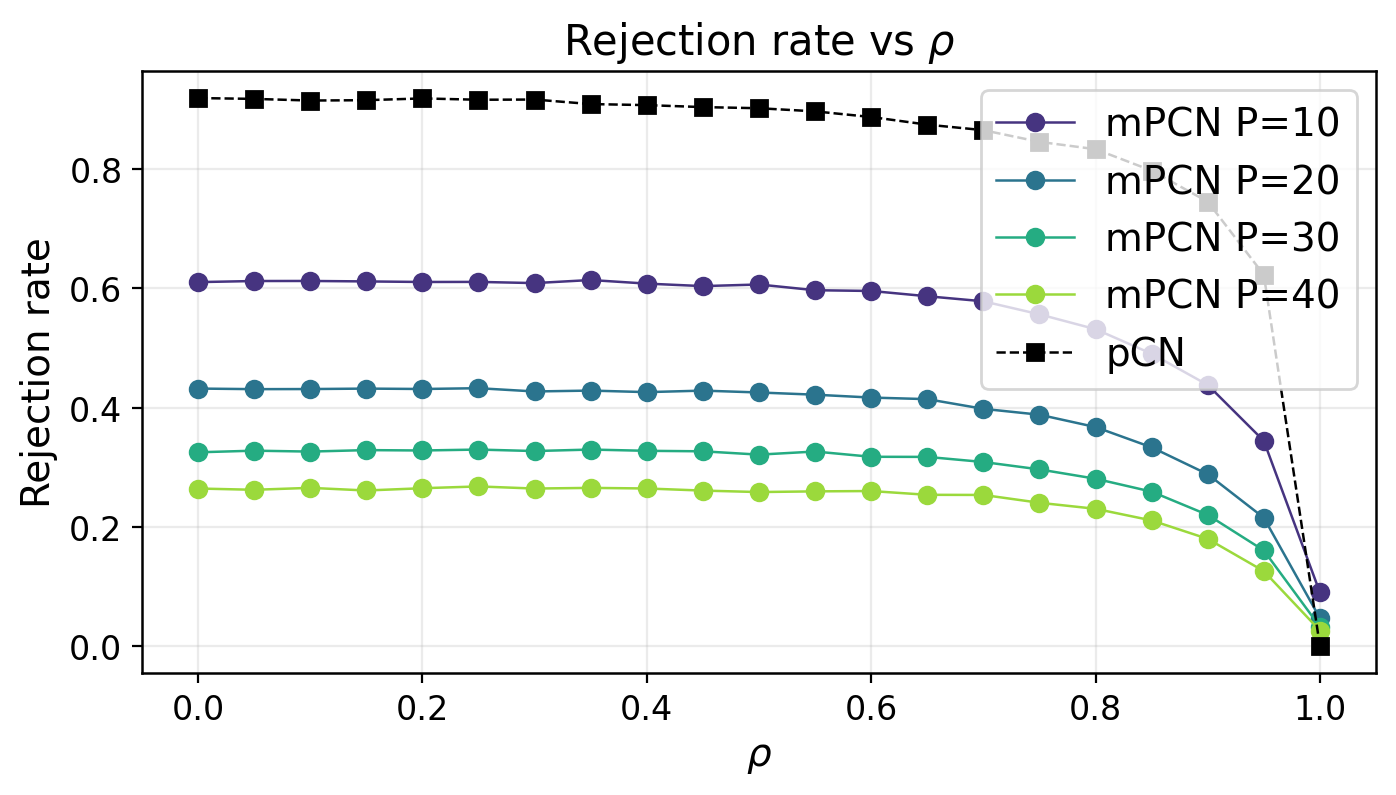

In [19]:
# Rejection rate vs rho (one line per P)
apply_pub_style()

P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}
show_pcn = True

pcn_reject = None
if run_pcn and results['pcn']:
    pcn_reject = [1.0 - results['pcn'][rho]['accept_rate'] for rho in rho_list]

reports_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.2), sharex=True)

for P in P_sorted:
    reject_vals = [1.0 - results['mpcn'][P][rho]['accept_rate'] for rho in rho_list]
    ax.plot(rho_list, reject_vals, marker='o', color=color_by_P[P], label=f'mPCN P={P}')
if show_pcn and pcn_reject is not None:
    ax.plot(rho_list, pcn_reject, color='black', marker='s', linestyle='--', label='pCN')

ax.set_xlabel(r'$\rho$')
ax.set_ylabel('Rejection rate')
ax.set_title(r'Rejection rate vs $\rho$')
ax.grid(alpha=0.25)
ax.legend(loc='best')

fig.tight_layout()
fig.savefig(reports_dir / f'multiwell_rejection_vs_rho_seed{seed_base}.png', bbox_inches='tight')
plt.show()

In [20]:
# ESS/MSJD tables (rows=P, columns=rho + pCN)
ess_rows = []
msjd_rows = []
row_labels = []
col_labels = [f'rho={rho:.3f}' for rho in rho_list]

for P in P_list:
    ess_row = [results['mpcn'][P][rho]['metrics']['ess_mean'] for rho in rho_list]
    msjd_row = [results['mpcn'][P][rho]['metrics']['msjd_mean'] for rho in rho_list]
    ess_rows.append(ess_row)
    msjd_rows.append(msjd_row)
    row_labels.append(f'P={P}')

if run_pcn and results['pcn']:
    ess_row = [results['pcn'][rho]['metrics']['ess_mean'] for rho in rho_list]
    msjd_row = [results['pcn'][rho]['metrics']['msjd_mean'] for rho in rho_list]
    ess_rows.append(ess_row)
    msjd_rows.append(msjd_row)
    row_labels.append('pCN')

ess_table = pd.DataFrame(ess_rows, index=row_labels, columns=col_labels)
msjd_table = pd.DataFrame(msjd_rows, index=row_labels, columns=col_labels)

# display tables rounding up to 0 decimal places
ess_table_display = ess_table.round(0).astype(int)
msjd_table_display = msjd_table.round(3)
print('ESS table (mPCN across rho; pCN row if enabled):')
display(ess_table_display)
print('MSJD table (mPCN across rho; pCN row if enabled):')
display(msjd_table_display)

ESS table (mPCN across rho; pCN row if enabled):


,rho=0.000,rho=0.050,rho=0.100,rho=0.150,rho=0.200,rho=0.250,rho=0.300,rho=0.350,rho=0.400,rho=0.450,...,rho=0.550,rho=0.600,rho=0.650,rho=0.700,rho=0.750,rho=0.800,rho=0.850,rho=0.900,rho=0.950,rho=1.000
P=10,9083,9129,8233,8501,8273,7850,7799,7572,6689,6603,...,5277,4844,4381,3496,2979,2362,1940,1265,7859,0
P=20,15715,16184,15819,15480,14625,14222,12836,11820,11415,10729,...,8437,7728,6283,5418,4511,3536,2321,1310,524,0
P=30,20823,20816,20333,20086,18978,18020,17285,16478,15412,13558,...,10207,9652,7849,6508,5254,3883,3016,1618,10894,0
P=40,24980,24869,24380,23884,22247,20912,19267,18301,17802,15994,...,12815,11288,9301,7661,6182,4373,3154,1898,629,0
pCN,1418,1525,1397,1231,1106,887,847,801,738,629,...,660,560,457,458,433,348,2599,2535,3009,0


MSJD table (mPCN across rho; pCN row if enabled):


,rho=0.000,rho=0.050,rho=0.100,rho=0.150,rho=0.200,rho=0.250,rho=0.300,rho=0.350,rho=0.400,rho=0.450,...,rho=0.550,rho=0.600,rho=0.650,rho=0.700,rho=0.750,rho=0.800,rho=0.850,rho=0.900,rho=0.950,rho=1.000
P=10,1.152,1.143,1.113,1.101,1.068,1.016,0.980,0.891,0.851,0.768,...,0.618,0.503,0.414,0.345,0.265,0.208,0.154,0.106,0.059,0.0
P=20,1.698,1.689,1.657,1.630,1.571,1.509,1.431,1.334,1.251,1.124,...,0.888,0.751,0.626,0.504,0.388,0.288,0.202,0.134,0.070,0.0
P=30,2.015,1.984,1.978,1.930,1.852,1.784,1.697,1.592,1.462,1.341,...,1.037,0.900,0.746,0.582,0.452,0.331,0.228,0.145,0.076,0.0
P=40,2.228,2.195,2.169,2.125,2.068,1.943,1.859,1.747,1.630,1.473,...,1.167,0.990,0.813,0.653,0.501,0.359,0.246,0.155,0.078,0.0
pCN,0.229,0.218,0.205,0.179,0.155,0.141,0.118,0.114,0.096,0.079,...,0.059,0.054,0.050,0.044,0.039,0.033,0.028,0.023,0.020,0.0


## Analyzing mixing for extreme $\rho$

In [ ]:
# Run extra rho chains for the edge ranges
rho_low = np.round(np.arange(0.0, 0.1001, 0.005), 5)
rho_high = np.round(np.arange(0.85, 1.0001, 0.005), 5)
rho_edges = np.unique(np.concatenate([rho_low, rho_high]))

def ensure_mpcn_rho_results(rho_values):
    for P in P_list:
        results['mpcn'].setdefault(P, {})
        for rho in rho_values:
            rho_key = float(rho)
            if rho_key in results['mpcn'][P]:
                continue
            samples_path, metrics_path = chain_cache_paths(
                'mpcn', rho=rho_key, seed_base=seed_base, P=P
            )
            diag_path = mpcn_diag_path(P, rho_key, seed_base)
            loaded = load_chain_bundle(samples_path, metrics_path)
            if loaded is not None:
                chain, accept_rate, runtime_sec, metrics = loaded
                if metrics is None or 'ess_per_param' not in metrics:
                    metrics = summarize_chain_metrics(
                        chain, runtime_sec, burn_in=burn_in, max_lag=max_lag
                    )
                    save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)
                snapshot, mean_dist_samples, mean_sq_dist_samples = load_mpcn_diagnostics(diag_path)
                results['mpcn'][P][rho_key] = {
                    'chain': chain,
                    'runtime_sec': runtime_sec,
                    'accept_rate': accept_rate,
                    'metrics': metrics,
                    'snapshot': snapshot,
                    'mean_dist_samples': np.asarray(mean_dist_samples, dtype=float),
                    'mean_sq_dist_samples': np.asarray(mean_sq_dist_samples, dtype=float),
                }
                accept_display = np.nan if accept_rate is None else accept_rate
                print(
                    f'mPCN edge rho loaded: P={P}, rho={rho_key:.3f}, '
                    f'accept={accept_display:.3f}, runtime={runtime_sec:.2f}s'
                )
                continue
            seed = seed_base + int(P * 1000 + round(rho_key * 1000))

            chain, runtime_sec, accept_rate, _ = run_mpcn_chain(
                problem,
                x0,
                n_iters,
                rho=rho_key,
                n_props=P,
                seed=seed,
                diag_indices=None,
            )
            metrics = summarize_chain_metrics(chain, runtime_sec, burn_in=burn_in, max_lag=max_lag)
            save_chain_bundle(samples_path, metrics_path, chain, accept_rate, runtime_sec, metrics)
            save_mpcn_diagnostics(diag_path, None, [], [])
            results['mpcn'][P][rho_key] = {
                'chain': chain,
                'runtime_sec': runtime_sec,
                'accept_rate': accept_rate,
                'metrics': metrics,
                'snapshot': None,
                'mean_dist_samples': np.asarray([], dtype=float),
                'mean_sq_dist_samples': np.asarray([], dtype=float),
            }
            print(
                f'mPCN edge rho done: P={P}, rho={rho_key:.3f}, '
                f'accept={accept_rate:.3f}, runtime={runtime_sec:.2f}s'
            )

ensure_mpcn_rho_results(rho_edges)


In [ ]:
# Zoomed-in rho ranges (0-0.1 and 0.9-1.0)
apply_pub_style()

rho_low = np.round(np.arange(0.0, 0.1001, 0.005), 5)
rho_high = np.round(np.arange(0.85, 1.0001, 0.005), 5)

P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}

def get_metric_for_rho(results_dict, P, rho, metric_key):
    entry = results_dict.get(P, {}).get(float(rho))
    if entry is None:
        return np.nan
    return entry['metrics'][metric_key]

reports_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), sharey=True)
ax_low, ax_high = axes

for P in P_sorted:
    ess_low = [get_metric_for_rho(results['mpcn'], P, rho, 'ess_mean') for rho in rho_low]
    ess_high = [get_metric_for_rho(results['mpcn'], P, rho, 'ess_mean') for rho in rho_high]
    ax_low.plot(rho_low, ess_low, marker='o', color=color_by_P[P], label=f'P={P}')
    ax_high.plot(rho_high, ess_high, marker='o', color=color_by_P[P], label=f'P={P}')

ax_low.set_title(r'ESS vs $\rho$ (0.0-0.1)')
ax_low.set_xlabel(r'$\rho$')
ax_low.set_ylabel('Effective Sample Size')
ax_low.grid(alpha=0.25)

ax_high.set_title(r'ESS vs $\rho$ (0.9-1.0)')
ax_high.set_xlabel(r'$\rho$')
ax_high.grid(alpha=0.25)

handles, labels = ax_low.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(r'Multiwell: ESS at $\rho$ range edges')
fig.tight_layout()

filename = f'multiwell_ess_rho_edges_0.00-0.10_0.85-1.00_seed{seed_base}.png'
fig.savefig(reports_dir / filename, bbox_inches='tight')
plt.show()

In [ ]:
# Zoomed-in MSJD vs rho (0-0.1 and 0.9-1.0)
apply_pub_style()

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), sharey=True)
ax_low, ax_high = axes

for P in P_sorted:
    msjd_low = [get_metric_for_rho(results['mpcn'], P, rho, 'msjd_mean') for rho in rho_low]
    msjd_high = [get_metric_for_rho(results['mpcn'], P, rho, 'msjd_mean') for rho in rho_high]
    ax_low.plot(rho_low, msjd_low, marker='o', color=color_by_P[P], label=f'P={P}')
    ax_high.plot(rho_high, msjd_high, marker='o', color=color_by_P[P], label=f'P={P}')

ax_low.set_title(r'MSJD vs $\rho$ (0.0-0.1)')
ax_low.set_xlabel(r'$\rho$')
ax_low.set_ylabel('MSJD')
ax_low.grid(alpha=0.25)

ax_high.set_title(r'MSJD vs $\rho$ (0.9-1.0)')
ax_high.set_xlabel(r'$\rho$')
ax_high.grid(alpha=0.25)

handles, labels = ax_low.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(r'Multiwell: MSJD at $\rho$ range edges')
fig.tight_layout()

filename = f'multiwell_msjd_rho_edges_0.00-0.10_0.85-1.00_seed{seed_base}.png'
fig.savefig(reports_dir / filename, bbox_inches='tight')
plt.show()

In [ ]:

# Edge rho ranges combined
rho_low = np.round(np.arange(0.0, 0.1001, 0.005), 5)
rho_high = np.round(np.arange(0.85, 1.0001, 0.005), 5)
rho_edges = np.unique(np.concatenate([rho_low, rho_high]))
rho_edges = rho_high

fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.0), sharex=True)
for P in P_sorted:
    ess_x1 = [get_param_metric(results['mpcn'], P, rho, 'ess_per_param', 0) for rho in rho_edges]
    ess_x2 = [get_param_metric(results['mpcn'], P, rho, 'ess_per_param', 1) for rho in rho_edges]
    msjd_x1 = [get_param_metric(results['mpcn'], P, rho, 'msjd_per_param', 0) for rho in rho_edges]
    msjd_x2 = [get_param_metric(results['mpcn'], P, rho, 'msjd_per_param', 1) for rho in rho_edges]
    axes[0, 0].plot(rho_edges, ess_x1, marker='o', color=color_by_P[P], label=f'mPCN P={P}')
    axes[1, 0].plot(rho_edges, ess_x2, marker='o', color=color_by_P[P])
    axes[0, 1].plot(rho_edges, msjd_x1, marker='o', color=color_by_P[P])
    axes[1, 1].plot(rho_edges, msjd_x2, marker='o', color=color_by_P[P])

axes[0, 0].set_title('ESS (x1) edges')
axes[0, 1].set_title('MSJD (x1) edges')
axes[1, 0].set_title('ESS (x2) edges')
axes[1, 1].set_title('MSJD (x2) edges')
for ax in axes[1, :]:
    ax.set_xlabel(r'$\rho$')
axes[0, 0].set_ylabel('ESS')
axes[1, 0].set_ylabel('ESS')
axes[0, 1].set_ylabel('MSJD')
axes[1, 1].set_ylabel('MSJD')
for ax in axes.ravel():
    ax.grid(alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(r'Multiwell: ESS/MSJD per-parameter at $\rho$ edges')
fig.tight_layout()
fig.savefig(
    reports_dir / f'multiwell_ess_msjd_per_param_rho_edges_0.85-1.00_seed{seed_base}.png',
    bbox_inches='tight',
)
plt.show()

In [ ]:
# Rejection rate vs rho (edge ranges)
apply_pub_style()

rho_low = np.round(np.arange(0.0, 0.1001, 0.005), 5)
rho_high = np.round(np.arange(0.85, 1.0001, 0.005), 5)

P_sorted = sorted(P_list)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(P_sorted)))
color_by_P = {P: colors[i] for i, P in enumerate(P_sorted)}

def get_reject_rate(results_dict, P, rho):
    entry = results_dict.get(P, {}).get(float(rho))
    if entry is None:
        return np.nan
    accept_rate = entry.get('accept_rate')
    if accept_rate is None:
        return np.nan
    return 1.0 - accept_rate

reports_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), sharey=True)
ax_low, ax_high = axes

for P in P_sorted:
    reject_low = [get_reject_rate(results['mpcn'], P, rho) for rho in rho_low]
    reject_high = [get_reject_rate(results['mpcn'], P, rho) for rho in rho_high]
    ax_low.plot(rho_low, reject_low, marker='o', color=color_by_P[P], label=f'P={P}')
    ax_high.plot(rho_high, reject_high, marker='o', color=color_by_P[P], label=f'P={P}')

ax_low.set_title(r'Rejection rate vs $\rho$ (0.0-0.1)')
ax_low.set_xlabel(r'$\rho$')
ax_low.set_ylabel('Rejection rate')
ax_low.grid(alpha=0.25)

ax_high.set_title(r'Rejection rate vs $\rho$ (0.9-1.0)')
ax_high.set_xlabel(r'$\rho$')
ax_high.grid(alpha=0.25)

handles, labels = ax_low.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(r'Multiwell: rejection rate at $\rho$ range edges')
fig.tight_layout()

filename = f'multiwell_rejection_rho_edges_0.00-0.10_0.85-1.00_seed{seed_base}.png'
fig.savefig(reports_dir / filename, bbox_inches='tight')
plt.show()